# microAutoware latency evaluation
## Latency data processing
---

### Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 

### Importing data

In [2]:

csv_file = '03122024_112729_latencies_without_autoware_manual'

csv_df = pd.read_csv('../data/'+csv_file+'.csv')
print(csv_df)
column_names = csv_df.columns
print(column_names)

       #  Latency steering  Period steering  Latency velocity  Period velocity
0      1                -1               -1          25374464         52611220
1      2          28656128         52829700                -1               -1
2      3                -1               -1          25537280        163802915
3      4          28722944        163706891                -1               -1
4      5                -1               -1          22542592         69755183
..   ...               ...              ...               ...              ...
979  980          29633280         62886999                -1               -1
980  981                -1               -1          26901504        160573143
981  982          30099456        160573479                -1               -1
982  983                -1               -1          25964544         59915611
983  984          29229056         59981784                -1               -1

[984 rows x 5 columns]
Index(['#', 'Latency steerin

### Getting vectors of latencies and periods

In [3]:
steering_latency_raw = csv_df['Latency steering'].to_list()
steering_period_raw = csv_df['Period steering'].to_list()
velocity_latency_raw = csv_df['Latency velocity'].to_list()
velocity_period_raw = csv_df['Period velocity'].to_list()

steering_latency = np.array([x for x in steering_latency_raw  if x >= 0])
steering_period = np.array([x for x in steering_period_raw  if x >= 0])
velocity_latency = np.array([x for x in velocity_latency_raw  if x >= 0])
velocity_period = np.array([x for x in velocity_period_raw  if x >= 0])

steering_latency_mean = steering_latency.mean()
steering_latency_std = steering_latency.std()

steering_period_mean = steering_period.mean()
steering_period_std = steering_period.std()

steering_count_not_real_time = 0

for l, p in zip(steering_latency, steering_period):
    if l > p:
        steering_count_not_real_time = steering_count_not_real_time + 1
        
steering_perc_not_real_time = steering_count_not_real_time/steering_latency.size

velocity_latency_mean = velocity_latency.mean()
velocity_latency_std = velocity_latency.std()

velocity_period_mean = velocity_period.mean()
velocity_period_std = velocity_period.std()

velocity_count_not_real_time = 0

for l, p in zip(velocity_latency, velocity_period):
    if l > p:
        velocity_count_not_real_time = velocity_count_not_real_time + 1
        
veloctiy_period_perc_not_real_time = velocity_count_not_real_time/velocity_latency.size



print("steering_latency_mean: "+str(steering_latency_mean))
print("steering_latency_std: "+str(steering_latency_std))
print("steering_period_mean: "+str(steering_period_mean))
print("steering_period_std: "+str(steering_period_std))
print("steering_perc_not_real_time: "+str(steering_perc_not_real_time))
print("")
print("velocity_latency_mean: "+str(velocity_latency_mean))
print("velocity_latency_std: "+str(velocity_latency_std))
print("velocity_period_mean: "+str(velocity_period_mean))
print("velocity_period_std: "+str(velocity_period_std))
print("velocity_count_not_real_time: "+str(velocity_count_not_real_time))
print("")



steering_latency_mean: 28125882.796747968
steering_latency_std: 3846408.015476678
steering_period_mean: 114069988.63414635
steering_period_std: 48824828.80708325
steering_perc_not_real_time: 0.0

velocity_latency_mean: 24684471.67479675
velocity_latency_std: 3716562.0032564485
velocity_period_mean: 114069570.24796748
velocity_period_std: 48732747.18302004
velocity_count_not_real_time: 0



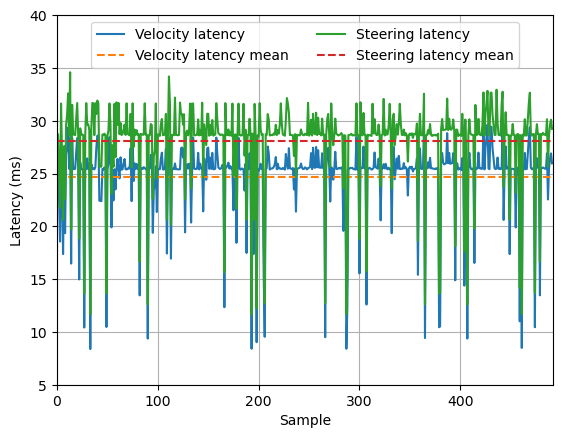

In [21]:
plt.figure()
plt.plot(velocity_latency/1e6, label='Velocity latency')
plt.plot(np.ones(velocity_latency.size)*velocity_latency_mean/1e6, '--', label='Velocity latency mean')
plt.plot(steering_latency/1e6, label='Steering latency')
plt.plot(np.ones(steering_latency.size)*steering_latency_mean/1e6, '--', label='Steering latency mean')
plt.legend(loc = 'upper center', ncol=2)
plt.ylim([0.5e1, 4e1])
plt.xlim([0, steering_latency.size])
plt.xlabel("Sample")
plt.ylabel("Latency (ms)")
plt.grid()